# 1. Текстовое описание набора данных

Для выполнения лабораторной работы был выбран датасет **Wine** из библиотеки `scikit-learn`.

**Источник данных:**
Данные являются результатом химического анализа вин, выращенных в одном регионе Италии. Три различных сорта вин были проанализированы, чтобы определить влияние химического состава на сорт.

**Содержание набора:**
Датасет содержит 178 образцов вин. Каждый образец описан 13 числовыми признаками (химическими характеристиками) и меткой класса, соответствующей сорту вина.

**Целевая переменная:**
*   `target` (Сорт вина): Три класса — 0, 1, 2.

**Признаки (химические характеристики):**
1.  `alcohol` - Алкоголь
2.  `malic_acid` - Яблочная кислота
3.  `ash` - Зольность
4.  `alcalinity_of_ash` - Щелочность золы
5.  `magnesium` - Магний
6.  `total_phenols` - Общее содержание фенолов
7.  `flavanoids` - Флавоноиды
8.  `nonflavanoid_phenols` - Нефлавоноидные фенолы
9.  `proanthocyanins` - Проантоцианидины
10. `color_intensity` - Интенсивность цвета
11. `hue` - Оттенок
12. `od280/od315_of_diluted_wines` - Оптическая плотность (характеристика белка)
13. `proline` - Пролин (аминокислота)


Импортируем библиотеки с помощью команды import.

In [1]:
# Импорт библиотек
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
sns.set(style="ticks")
from sklearn.datasets import load_wine


In [7]:
# Загрузка данных
wine = load_wine()

# Создаем DataFrame с данными
data = pd.DataFrame(data=wine.data, columns=wine.feature_names)
# Добавляем целевой признак
data['target'] = wine.target


## 2) Основные характеристики датасета

In [3]:
# Первые 5 строк датасета
data.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [6]:
data.shape

(178, 14)

In [7]:
total_count = data.shape[0]
print('Всего строк: {}'.format(total_count))

Всего строк: 178


In [11]:
# Список колонок
for column in data.columns:
    print(column)

alcohol
malic_acid
ash
alcalinity_of_ash
magnesium
total_phenols
flavanoids
nonflavanoid_phenols
proanthocyanins
color_intensity
hue
od280/od315_of_diluted_wines
proline
target


In [12]:
# Список колонок с типами данных
data.dtypes

alcohol                         float64
malic_acid                      float64
ash                             float64
alcalinity_of_ash               float64
magnesium                       float64
total_phenols                   float64
flavanoids                      float64
nonflavanoid_phenols            float64
proanthocyanins                 float64
color_intensity                 float64
hue                             float64
od280/od315_of_diluted_wines    float64
proline                         float64
target                            int64
dtype: object

In [13]:
# Проверим наличие пустых значений
# Цикл по колонкам датасета
for col in data.columns:
    # Количество пустых значений - все значения заполнены
    temp_null_count = data[data[col].isnull()].shape[0]
    print('{} - {}'.format(col, temp_null_count))

alcohol - 0
malic_acid - 0
ash - 0
alcalinity_of_ash - 0
magnesium - 0
total_phenols - 0
flavanoids - 0
nonflavanoid_phenols - 0
proanthocyanins - 0
color_intensity - 0
hue - 0
od280/od315_of_diluted_wines - 0
proline - 0
target - 0


In [14]:
# Основные статистические характеристики набора данных
data.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


In [15]:
# Определим уникальные значения для целевого признака
data['target'].unique()

array([0, 1, 2])

Целевой признак содержит три класса: 0, 1 и 2.


## 3) Визуальное исследование датасета

Для визуального исследования могут быть использованы различные виды диаграмм. Мы построим несколько вариантов, которые используются достаточно часто.

### Диаграмма рассеяния

Позволяет построить распределение двух колонок данных и визуально обнаружить наличие зависимости. Не предполагается, что значения упорядочены (например, по времени).

<Axes: xlabel='alcohol', ylabel='malic_acid'>

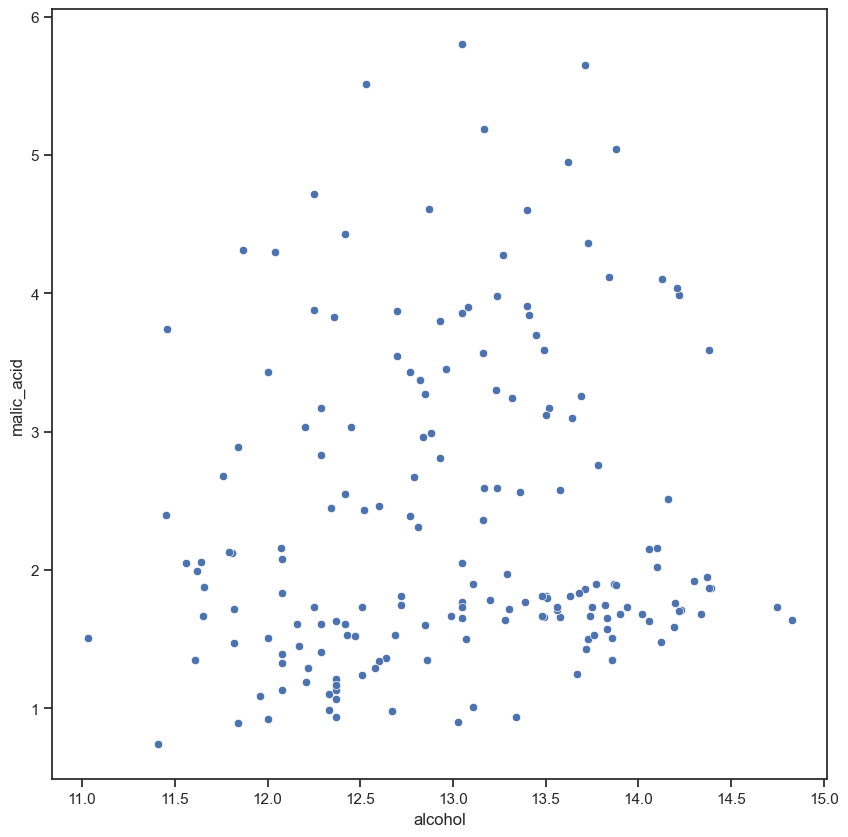

In [16]:
fig, ax = plt.subplots(figsize=(10,10))
sns.scatterplot(ax=ax, x='alcohol', y='malic_acid', data=data)

Можно видеть, что точки распределены довольно хаотично, однако прослеживается тенденция: при высоком содержании алкоголя содержание яблочной кислоты обычно ниже.

Посмотрим насколько на эту зависимость влияет целевой признак (сорт вина).


<Axes: xlabel='alcohol', ylabel='malic_acid'>

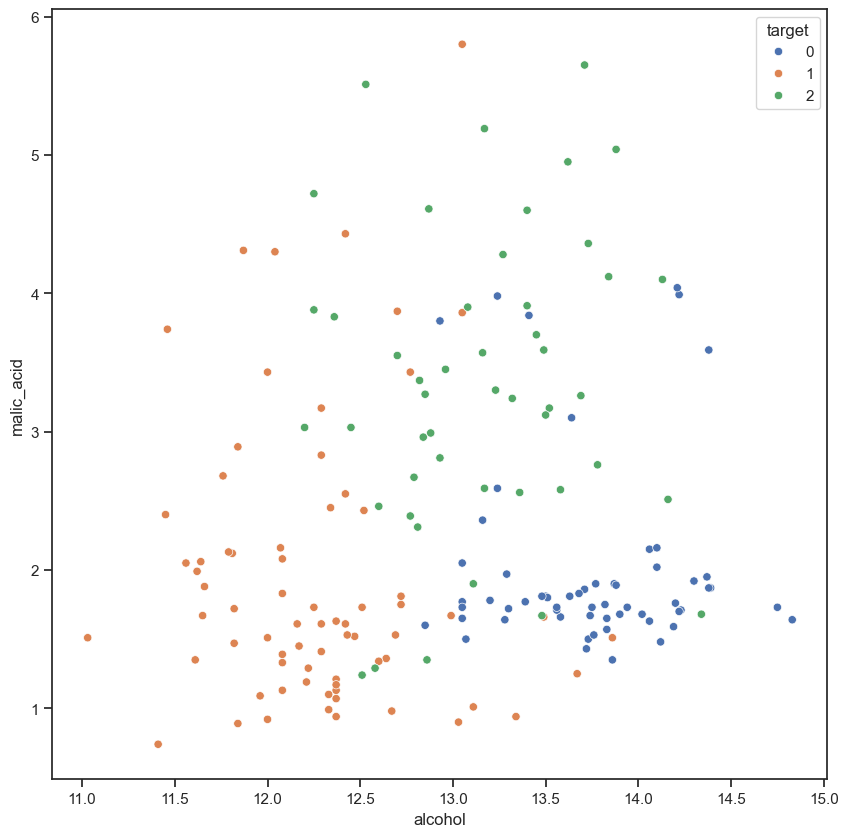

In [17]:
fig, ax = plt.subplots(figsize=(10,10))
sns.scatterplot(ax=ax, x='alcohol', y='malic_acid', data=data, hue='target', palette='deep')

### Гистограмма

Позволяет оценить плотность вероятности распределения данных.

Text(0.5, 1.0, 'Распределение содержания алкоголя')

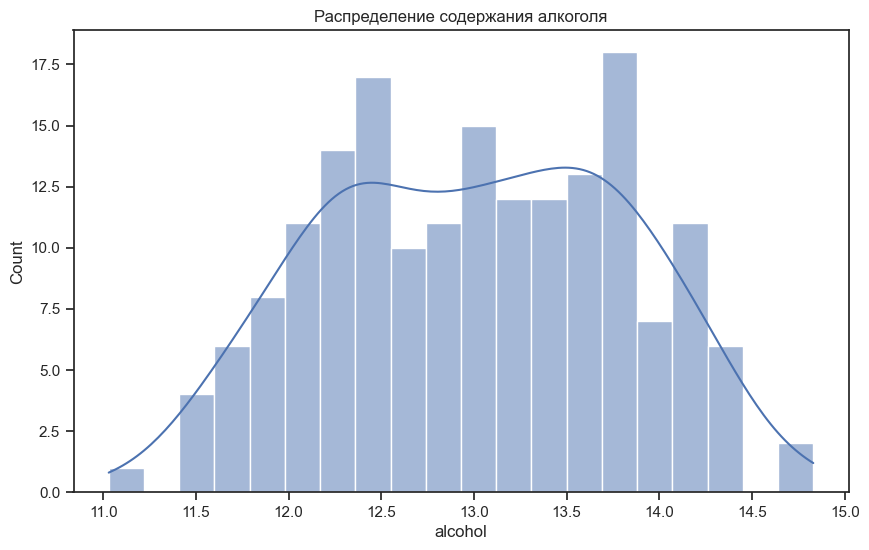

In [19]:
fig, ax = plt.subplots(figsize=(10,6))
sns.histplot(data['alcohol'], bins=20, kde=True)
plt.title('Распределение содержания алкоголя')

Комбинация гистограмм и диаграмм рассеивания.

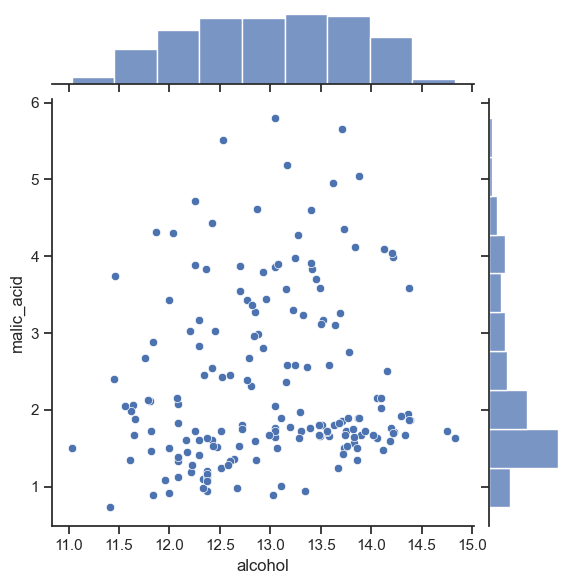

In [21]:
sns.jointplot(x='alcohol', y='malic_acid', data=data)

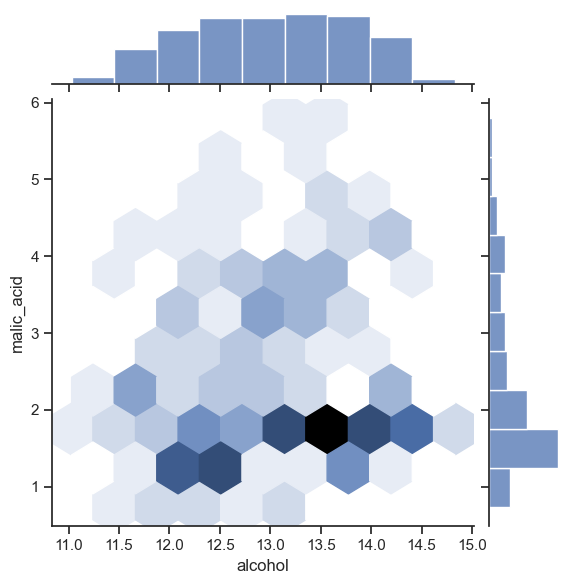

In [22]:
sns.jointplot(x='alcohol', y='malic_acid', data=data, kind="hex")

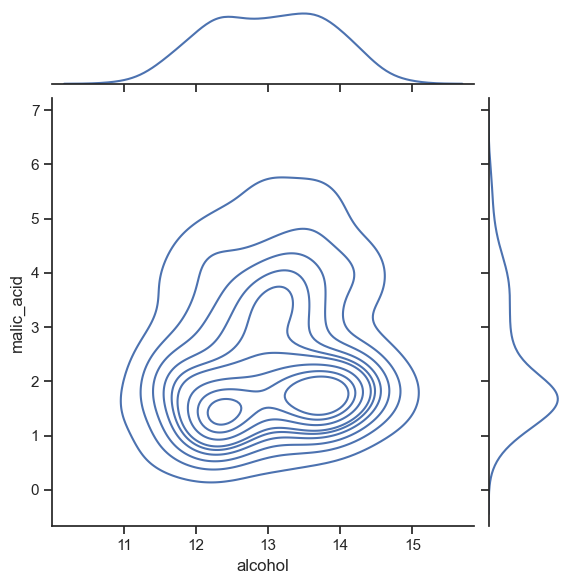

In [23]:
sns.jointplot(x='alcohol', y='malic_acid', data=data, kind="kde")

### "Парные диаграммы" (Pairplot)

Комбинация гистограмм и диаграмм рассеивания для всего набора данных.

Выводится матрица графиков. На пересечении строки и столбца, которые соответствуют двум показателям, строится диаграмма рассеивания. На главной диагонали матрицы строятся гистограммы распределения соответствующих показателей.

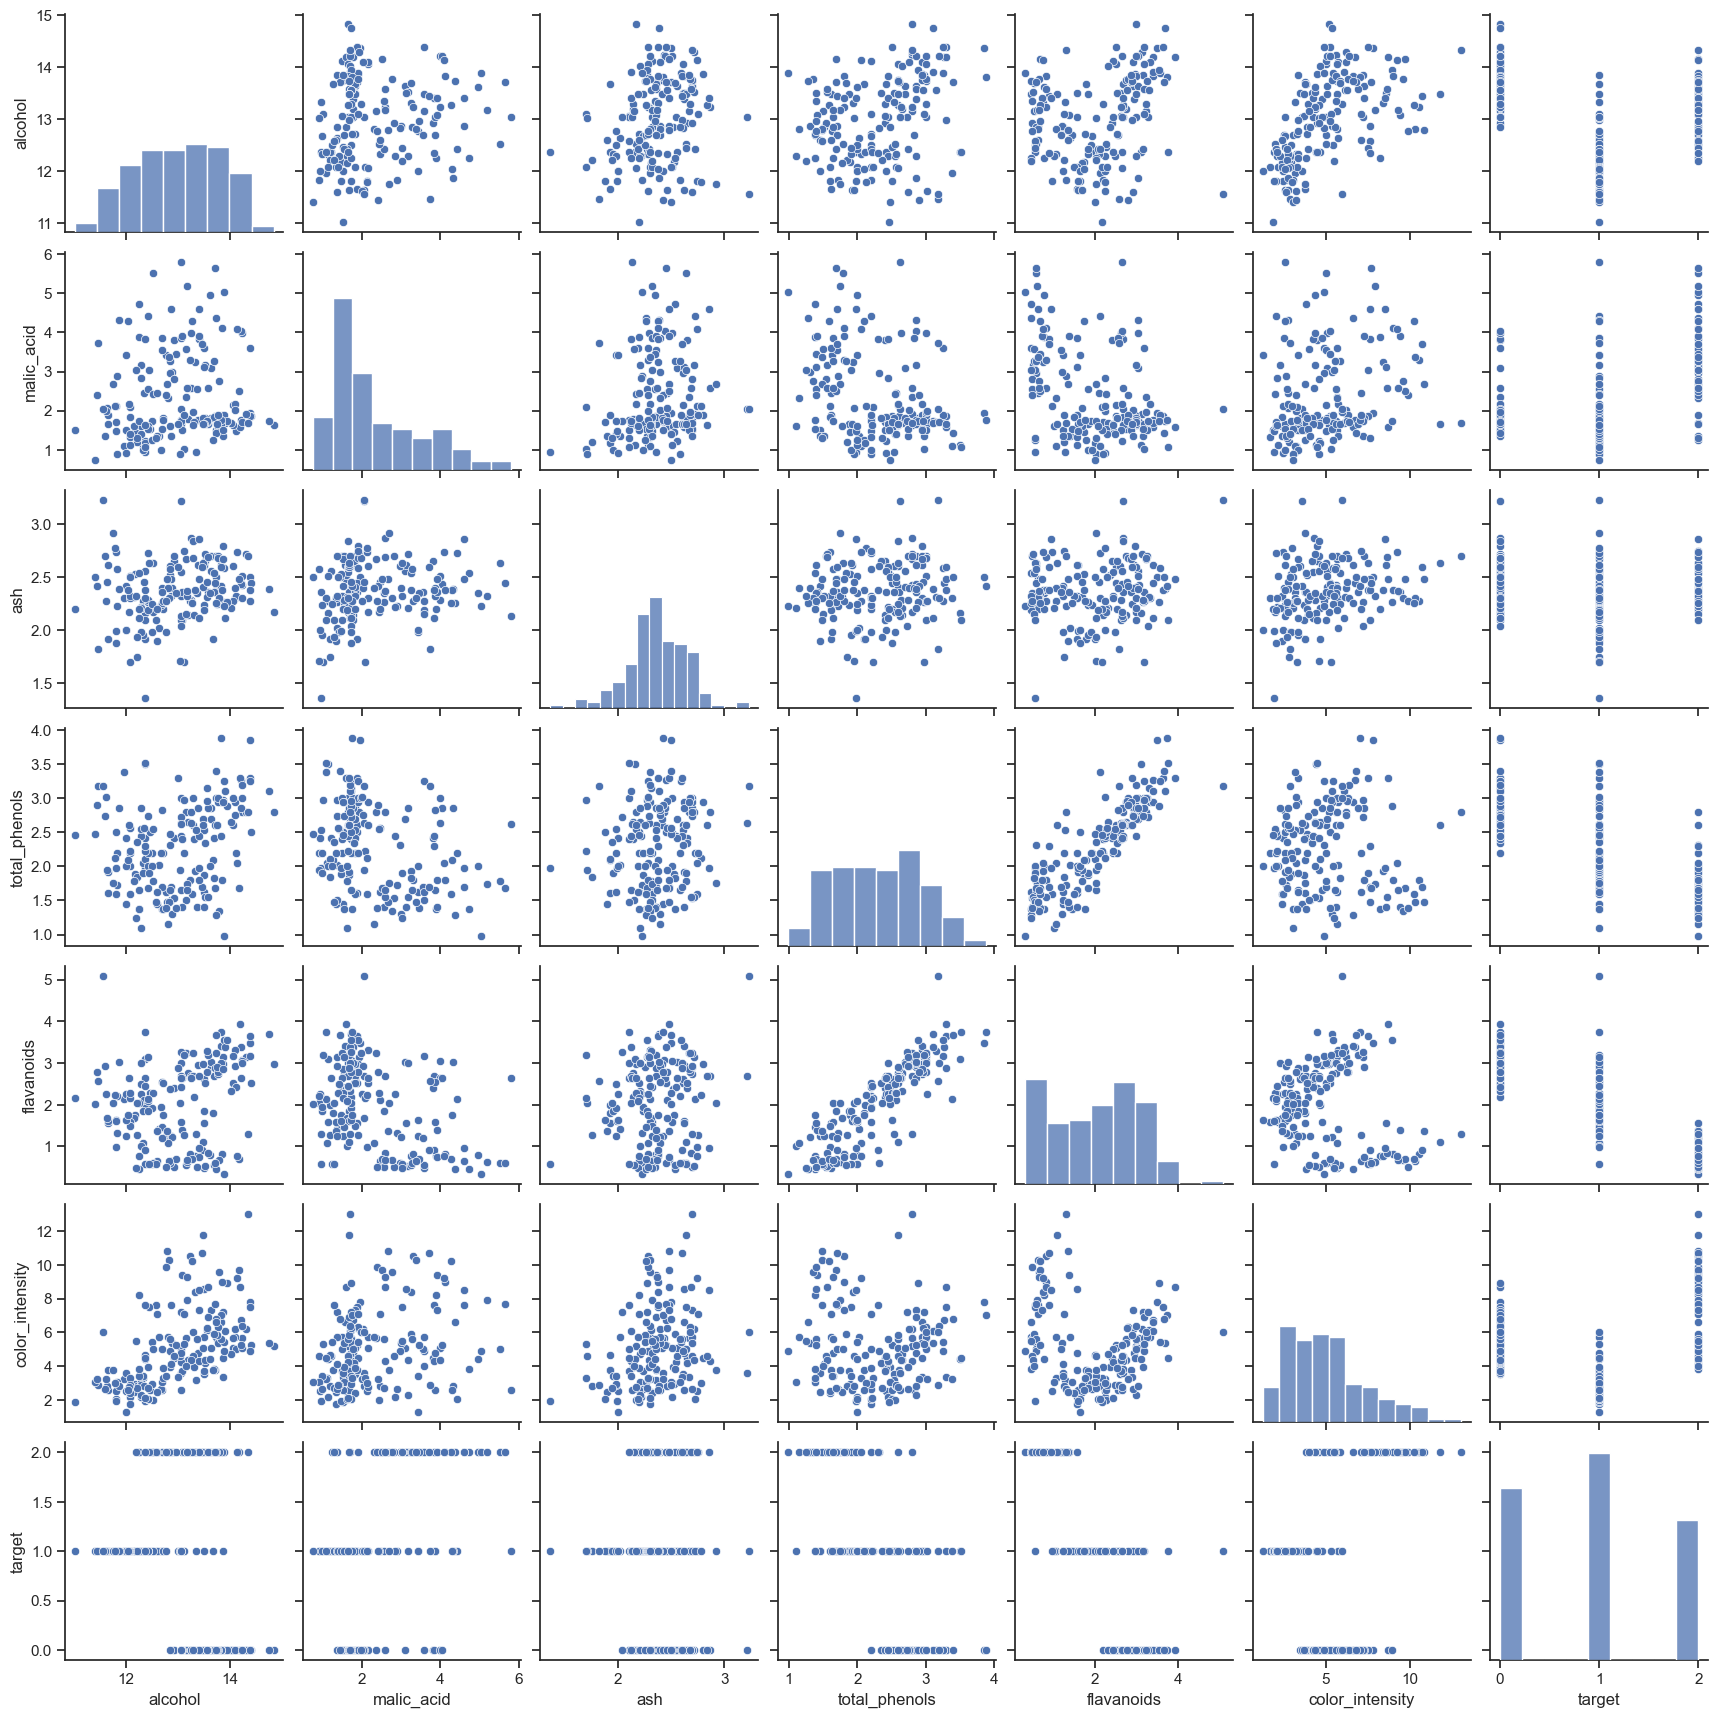

In [8]:
selected_features = ['alcohol', 'malic_acid', 'ash', 'total_phenols', 'flavanoids', 'color_intensity', 'target']
sns.pairplot(data[selected_features])

С помощью параметра `hue` возможна группировка по значениям какого-либо признака (в нашем случае - по сорту вина).

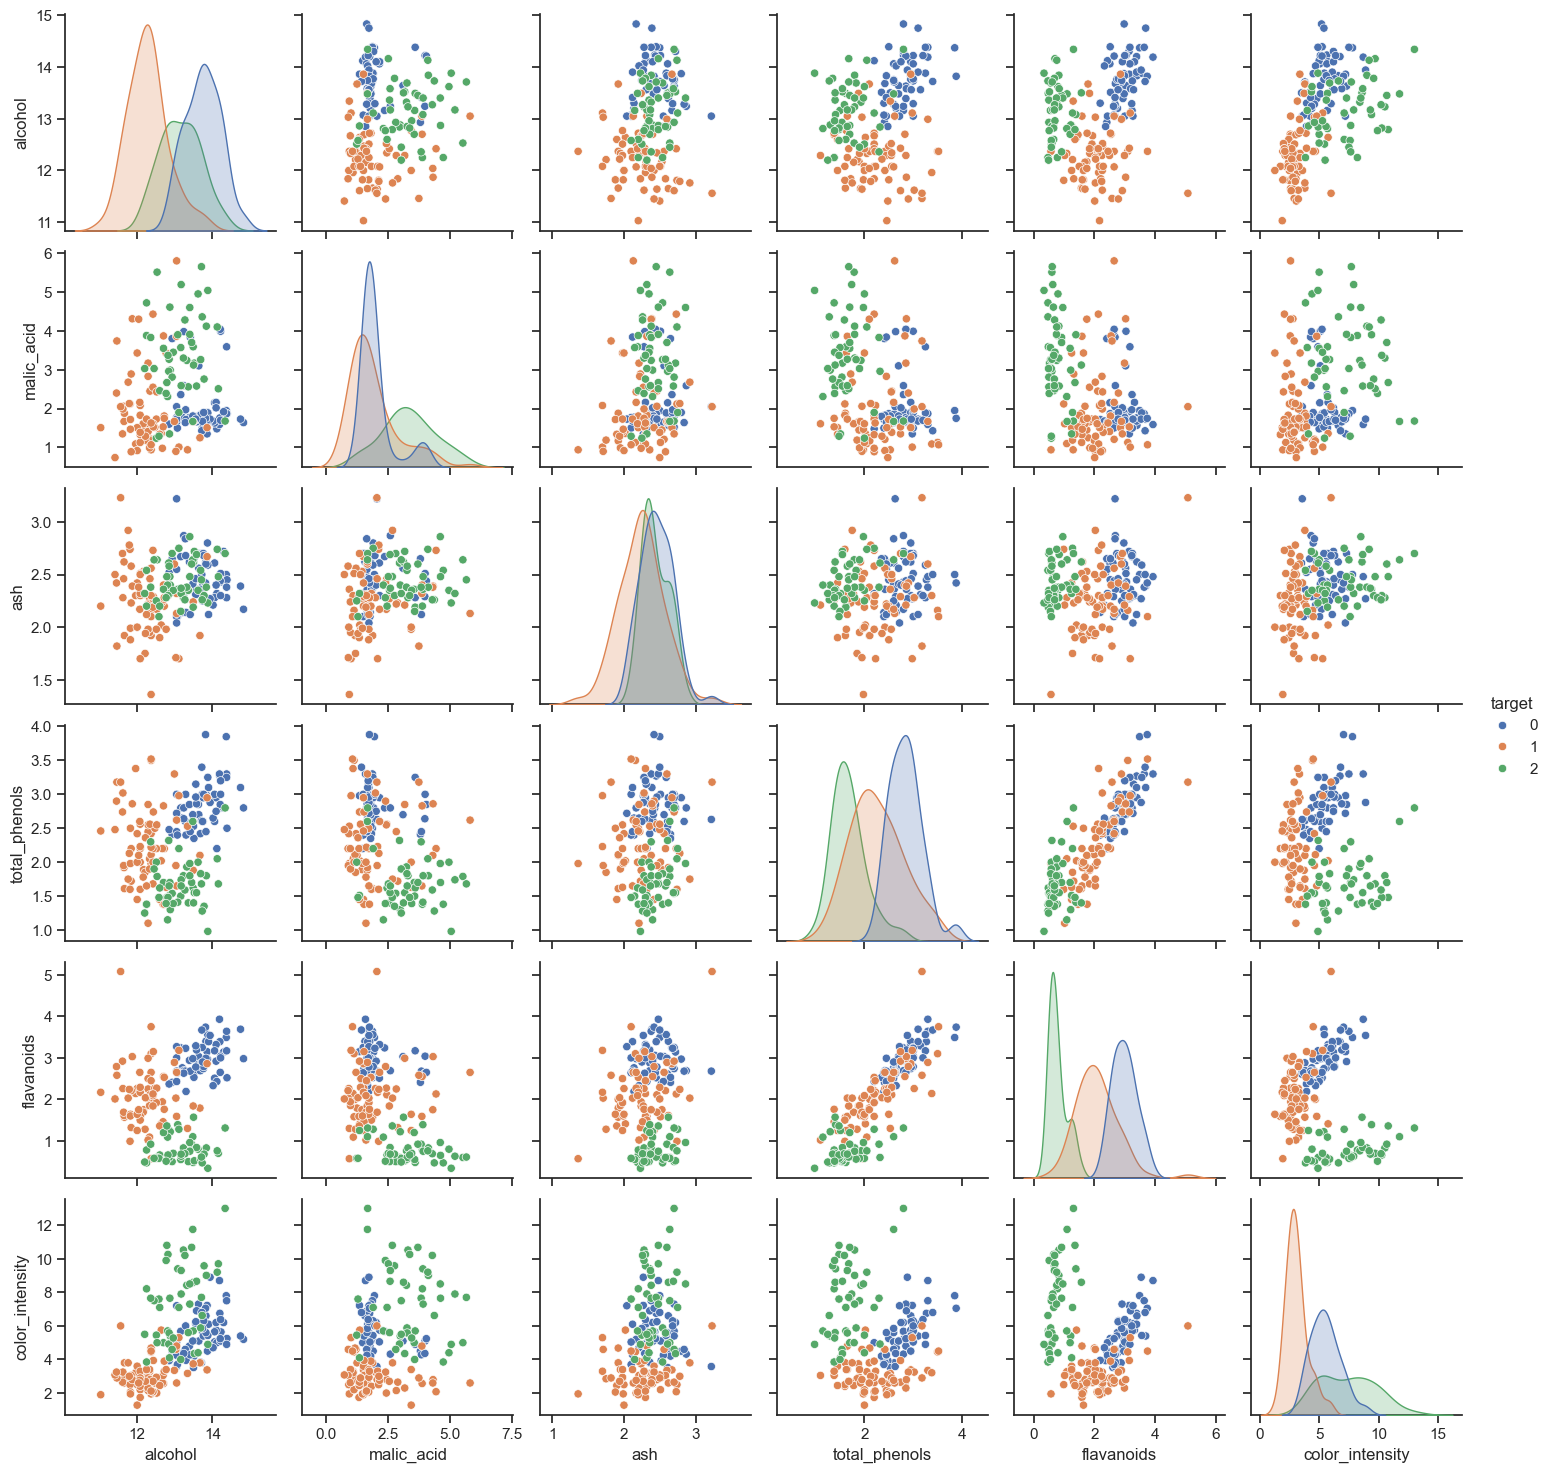

In [29]:
sns.pairplot(data[selected_features], hue="target", palette='deep')

На графиках видно, что некоторые признаки (например, flavanoids и total_phenols) хорошо разделяют сорта вин.

### Ящик с усами (Boxplot)

Отображает одномерное распределение вероятности.

<Axes: xlabel='alcohol'>

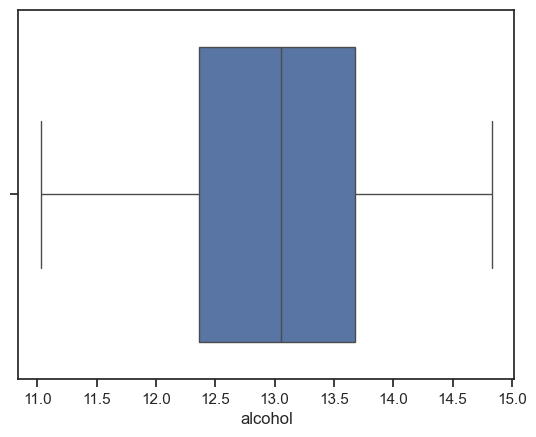

In [30]:
sns.boxplot(x=data['alcohol'])

<Axes: ylabel='alcohol'>

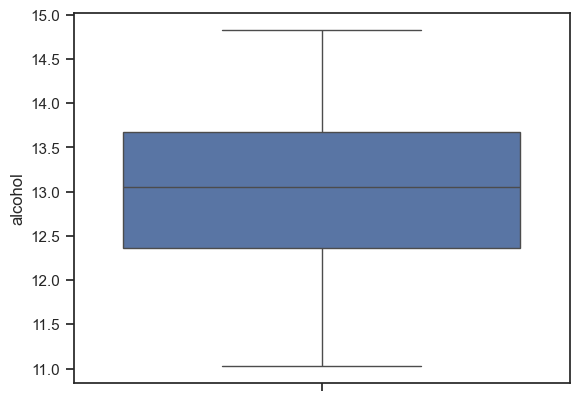

In [31]:
# По вертикали
sns.boxplot(y=data['alcohol'])

<Axes: xlabel='target', ylabel='alcohol'>

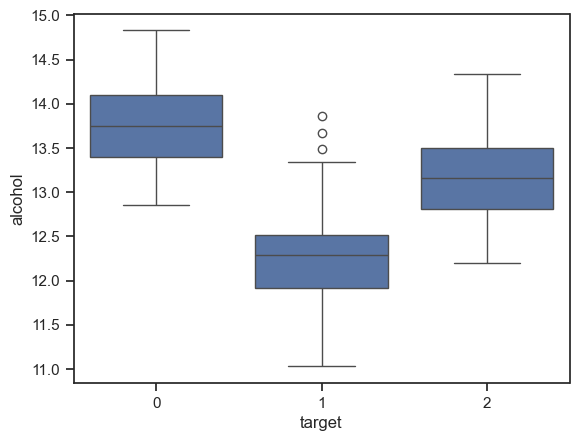

In [9]:
# Распределение параметра alcohol, сгруппированное по target 
sns.boxplot(x='target', y='alcohol', data=data)

Видно, что сорт 0 (класс 0) в среднем имеет самое высокое содержание алкоголя, а сорт 1 (класс 1) — самое низкое.

### Violin plot (Скрипичная диаграмма)

Похожа на предыдущую диаграмму, но по краям отображаются распределения плотности - https://en.wikipedia.org/wiki/Kernel_density_estimation

<Axes: xlabel='alcohol'>

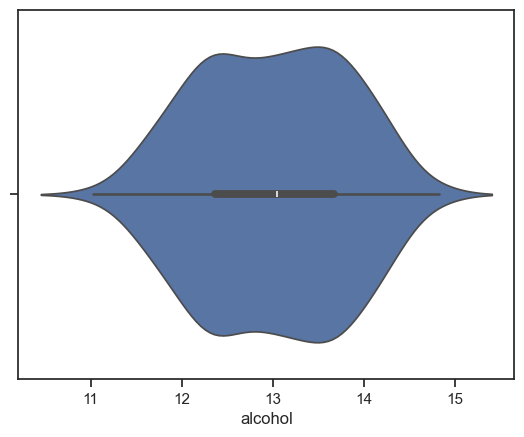

In [33]:
sns.violinplot(x=data['alcohol'])

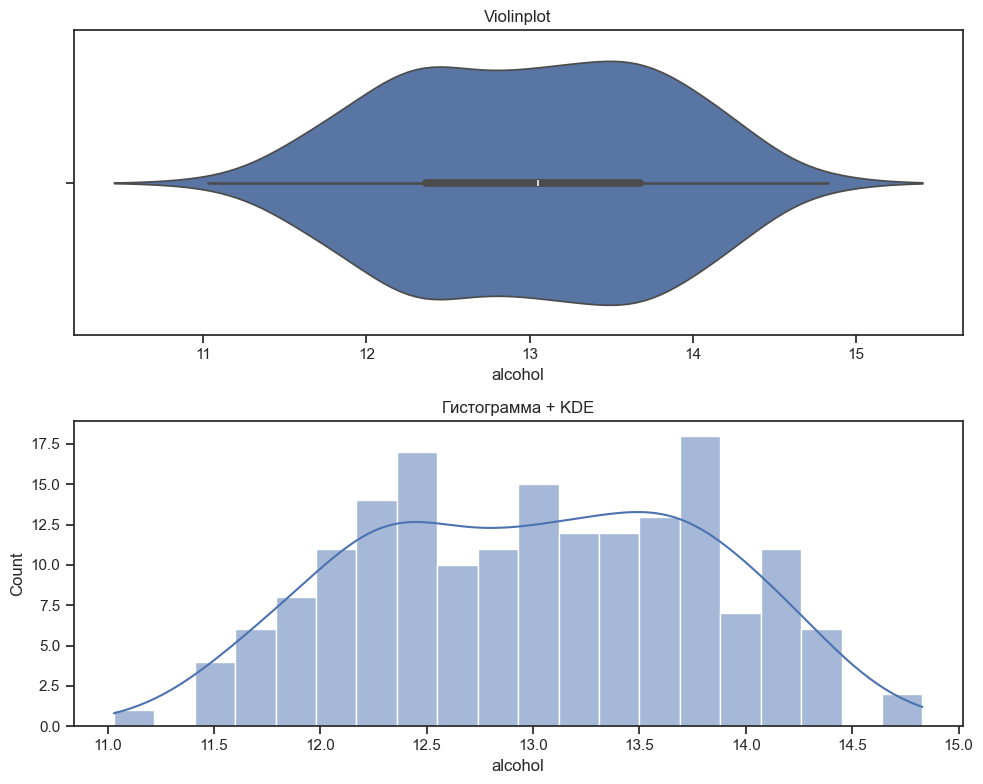

In [34]:
fig, ax = plt.subplots(2, 1, figsize=(10,8))
sns.violinplot(ax=ax[0], x=data['alcohol'])
sns.histplot(ax=ax[1], x=data['alcohol'], bins=20, kde=True)
ax[0].set_title('Violinplot')
ax[1].set_title('Гистограмма + KDE')
plt.tight_layout()


Из приведенных графиков видно, что violinplot действительно показывает распределение плотности.

<Axes: xlabel='target', ylabel='alcohol'>

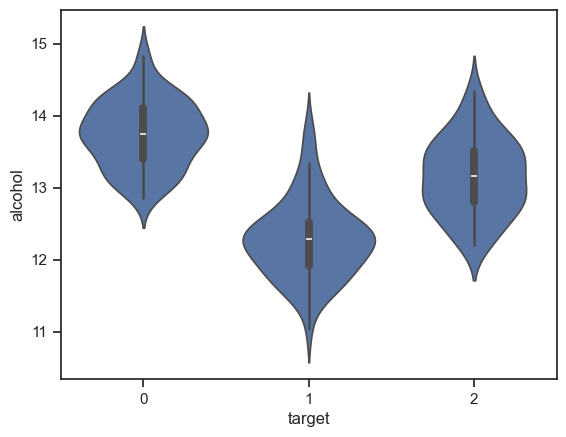

In [36]:
# Распределение параметра alcohol, сгруппированное по target
sns.violinplot(x='target', y='alcohol', data=data)

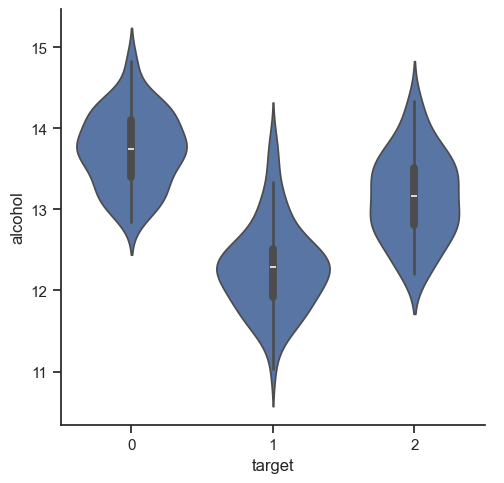

In [37]:
sns.catplot(y='alcohol', x='target', data=data, kind="violin", split=False)

## 4) Информация о корреляции признаков

Проверка корреляции признаков позволяет решить две задачи:

1.  Понять какие признаки (колонки датасета) наиболее сильно коррелируют с целевым признаком (в нашем примере это колонка "target"). Именно эти признаки будут наиболее информативными для моделей машинного обучения.
2.  Понять какие нецелевые признаки линейно зависимы между собой. Линейно зависимые признаки, как правило, очень плохо влияют на качество моделей. Поэтому если несколько признаков линейно зависимы, то для построения модели из них выбирают какой-то один признак.

In [10]:
corr_matrix = data.corr()
corr_matrix

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
alcohol,1.000000,0.094397,0.211545,-0.310235,0.270798,0.289101,0.236815,-0.155929,0.136698,0.546364,-0.071747,0.072343,0.643720,-0.328222
malic_acid,0.094397,1.000000,0.164045,0.288500,-0.054575,-0.335167,-0.411007,0.292977,-0.220746,0.248985,-0.561296,-0.368710,-0.192011,0.437776
ash,0.211545,0.164045,1.000000,0.443367,0.286587,0.128980,0.115077,0.186230,0.009652,0.258887,-0.074667,0.003911,0.223626,-0.049643
alcalinity_of_ash,-0.310235,0.288500,0.443367,1.000000,-0.083333,-0.321113,-0.351370,0.361922,-0.197327,0.018732,-0.273955,-0.276769,-0.440597,0.517859
magnesium,0.270798,-0.054575,0.286587,-0.083333,1.000000,0.214401,0.195784,-0.256294,0.236441,0.199950,0.055398,0.066004,0.393351,-0.209179
total_phenols,0.289101,-0.335167,0.128980,-0.321113,0.214401,1.000000,0.864564,-0.449935,0.612413,-0.055136,0.433681,0.699949,0.498115,-0.719163
flavanoids,0.236815,-0.411007,0.115077,-0.351370,0.195784,0.864564,1.000000,-0.537900,0.652692,-0.172379,0.543479,0.787194,0.494193,-0.847498
nonflavanoid_phenols,-0.155929,0.292977,0.186230,0.361922,-0.256294,-0.449935,-0.537900,1.000000,-0.365845,0.139057,-0.262640,-0.503270,-0.311385,0.489109
proanthocyanins,0.136698,-0.220746,0.009652,-0.197327,0.236441,0.612413,0.652692,-0.365845,1.000000,-0.025250,0.295544,0.519067,0.330417,-0.499130
color_intensity,0.546364,0.248985,0.258887,0.018732,0.199950,-0.055136,-0.172379,0.139057,-0.025250,1.000000,-0.521813,-0.428815,0.316100,0.265668


Корреляционная матрица содержит коэффициенты корреляции между всеми парами признаков.

Корреляционная матрица симметрична относительно главной диагонали. На главной диагонали расположены единицы (корреляция признака самого с собой).

На основе корреляционной матрицы можно сделать следующие выводы:

*   Целевой признак наиболее сильно коррелирует с содержанием флавоноидов (`flavanoids`, ~ -0.85) и общим содержанием фенолов (`total_phenols`, ~ -0.72). Знак минус означает, что с увеличением этих показателей номер сорта уменьшается (т.е. для сорта 0 эти показатели выше, для сорта 2 — ниже). Эти признаки обязательно следует оставить в модели.
*   Целевой признак также хорошо коррелирует с оптической плотностью (`od280/od315_of_diluted_wines`, ~ -0.79) и содержанием пролина (`proline`, ~ -0.63).
*   Признак `alcalinity_of_ash` слабо коррелирует с целевым признаком (~ 0.52), его можно попробовать исключить.
*   Наблюдается очень сильная корреляция между признаками `flavanoids` и `total_phenols` (~ 0.86). Это логично, так как флавоноиды являются подгруппой фенолов. Из этих двух признаков в модели можно оставить только один (скорее всего `flavanoids`, так как его корреляция с целевым признаком выше по модулю).
*   Также высокая корреляция наблюдается между `flavanoids` и `od280/od315_of_diluted_wines` (~ 0.79).

In [4]:

print("Корреляция Пирсона (по умолчанию):")
display(data.corr(method='pearson').round(3))

print("\nКорреляция Кендалла:")
display(data.corr(method='kendall').round(3))

print("\nКорреляция Спирмена:")
display(data.corr(method='spearman').round(3))

Корреляция Пирсона (по умолчанию):


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
alcohol,1.000,0.094,0.212,-0.310,0.271,0.289,0.237,-0.156,0.137,0.546,-0.072,0.072,0.644,-0.328
malic_acid,0.094,1.000,0.164,0.289,-0.055,-0.335,-0.411,0.293,-0.221,0.249,-0.561,-0.369,-0.192,0.438
ash,0.212,0.164,1.000,0.443,0.287,0.129,0.115,0.186,0.010,0.259,-0.075,0.004,0.224,-0.050
alcalinity_of_ash,-0.310,0.289,0.443,1.000,-0.083,-0.321,-0.351,0.362,-0.197,0.019,-0.274,-0.277,-0.441,0.518
magnesium,0.271,-0.055,0.287,-0.083,1.000,0.214,0.196,-0.256,0.236,0.200,0.055,0.066,0.393,-0.209
total_phenols,0.289,-0.335,0.129,-0.321,0.214,1.000,0.865,-0.450,0.612,-0.055,0.434,0.700,0.498,-0.719
flavanoids,0.237,-0.411,0.115,-0.351,0.196,0.865,1.000,-0.538,0.653,-0.172,0.543,0.787,0.494,-0.847
nonflavanoid_phenols,-0.156,0.293,0.186,0.362,-0.256,-0.450,-0.538,1.000,-0.366,0.139,-0.263,-0.503,-0.311,0.489
proanthocyanins,0.137,-0.221,0.010,-0.197,0.236,0.612,0.653,-0.366,1.000,-0.025,0.296,0.519,0.330,-0.499
color_intensity,0.546,0.249,0.259,0.019,0.200,-0.055,-0.172,0.139,-0.025,1.000,-0.522,-0.429,0.316,0.266



Корреляция Кендалла:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
alcohol,1.000,0.094,0.170,-0.213,0.251,0.209,0.191,-0.110,0.134,0.434,-0.022,0.062,0.449,-0.239
malic_acid,0.094,1.000,0.158,0.210,0.051,-0.175,-0.212,0.175,-0.169,0.196,-0.389,-0.163,-0.045,0.247
ash,0.170,0.158,1.000,0.258,0.254,0.090,0.049,0.099,0.018,0.188,-0.037,-0.006,0.172,-0.038
alcalinity_of_ash,-0.213,0.210,0.258,1.000,-0.121,-0.257,-0.310,0.278,-0.171,-0.057,-0.239,-0.226,-0.313,0.449
magnesium,0.251,0.051,0.254,-0.121,1.000,0.172,0.162,-0.158,0.118,0.242,0.024,0.034,0.343,-0.185
total_phenols,0.209,-0.175,0.090,-0.257,0.172,1.000,0.702,-0.310,0.467,0.028,0.289,0.478,0.280,-0.590
flavanoids,0.191,-0.212,0.049,-0.310,0.162,0.702,1.000,-0.378,0.535,0.029,0.354,0.520,0.264,-0.725
nonflavanoid_phenols,-0.110,0.175,0.099,0.278,-0.158,-0.310,-0.378,1.000,-0.269,0.036,-0.180,-0.364,-0.174,0.379
proanthocyanins,0.134,-0.169,0.018,-0.171,0.118,0.467,0.535,-0.269,1.000,-0.015,0.231,0.369,0.204,-0.450
color_intensity,0.434,0.196,0.188,-0.057,0.242,0.028,0.029,0.036,-0.015,1.000,-0.292,-0.206,0.317,0.065



Корреляция Спирмена:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
alcohol,1.000,0.140,0.244,-0.307,0.366,0.311,0.295,-0.162,0.193,0.635,-0.024,0.103,0.634,-0.354
malic_acid,0.140,1.000,0.231,0.304,0.080,-0.280,-0.325,0.255,-0.245,0.290,-0.560,-0.255,-0.057,0.347
ash,0.244,0.231,1.000,0.366,0.361,0.132,0.079,0.146,0.024,0.283,-0.050,-0.007,0.253,-0.054
alcalinity_of_ash,-0.307,0.304,0.366,1.000,-0.170,-0.377,-0.444,0.389,-0.254,-0.074,-0.353,-0.326,-0.456,0.570
magnesium,0.366,0.080,0.361,-0.170,1.000,0.246,0.233,-0.237,0.174,0.357,0.036,0.057,0.508,-0.250
total_phenols,0.311,-0.280,0.132,-0.377,0.246,1.000,0.879,-0.448,0.667,0.011,0.439,0.687,0.419,-0.727
flavanoids,0.295,-0.325,0.079,-0.444,0.233,0.879,1.000,-0.544,0.730,-0.043,0.535,0.742,0.430,-0.855
nonflavanoid_phenols,-0.162,0.255,0.146,0.389,-0.237,-0.448,-0.544,1.000,-0.385,0.060,-0.268,-0.495,-0.270,0.474
proanthocyanins,0.193,-0.245,0.024,-0.254,0.174,0.667,0.730,-0.385,1.000,-0.031,0.343,0.554,0.308,-0.571
color_intensity,0.635,0.290,0.283,-0.074,0.357,0.011,-0.043,0.060,-0.031,1.000,-0.419,-0.318,0.457,0.131


В случае большого количества признаков анализ числовой корреляционной матрицы становится неудобен.

Для визуализации корреляционной матрицы будем использовать "тепловую карту" heatmap, которая показывает степень корреляции различными цветами.

<Axes: >

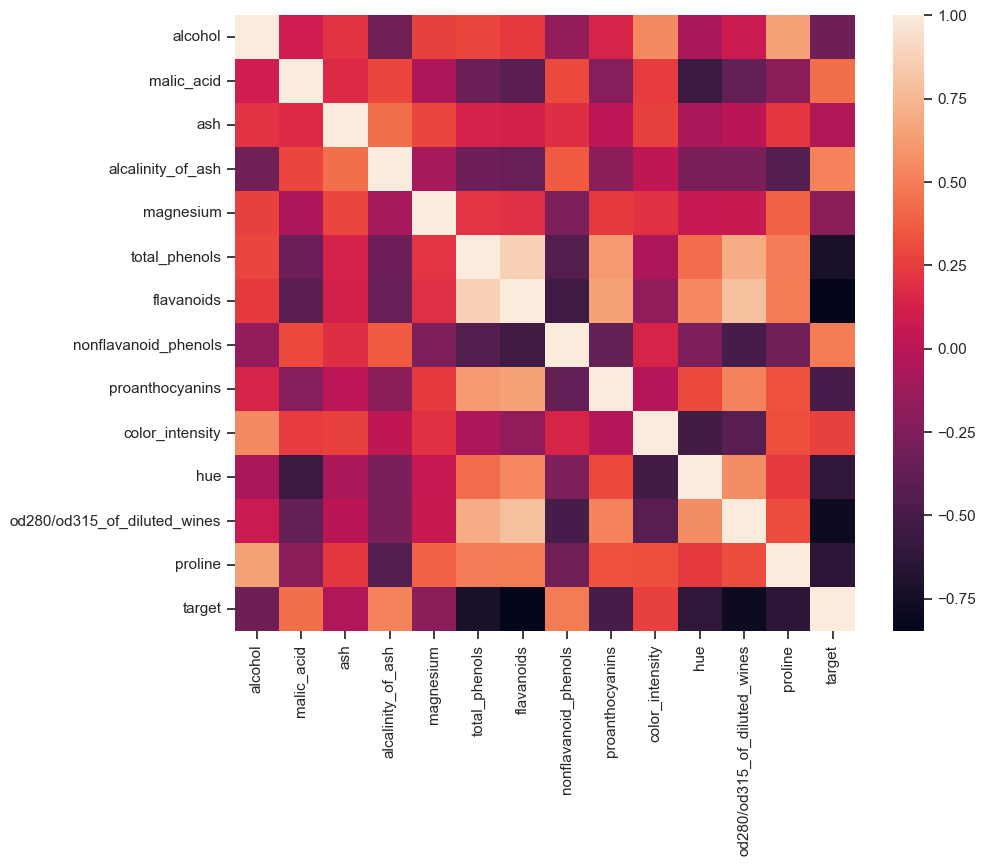

In [5]:
plt.figure(figsize=(10,8))
sns.heatmap(data.corr())

<Axes: >

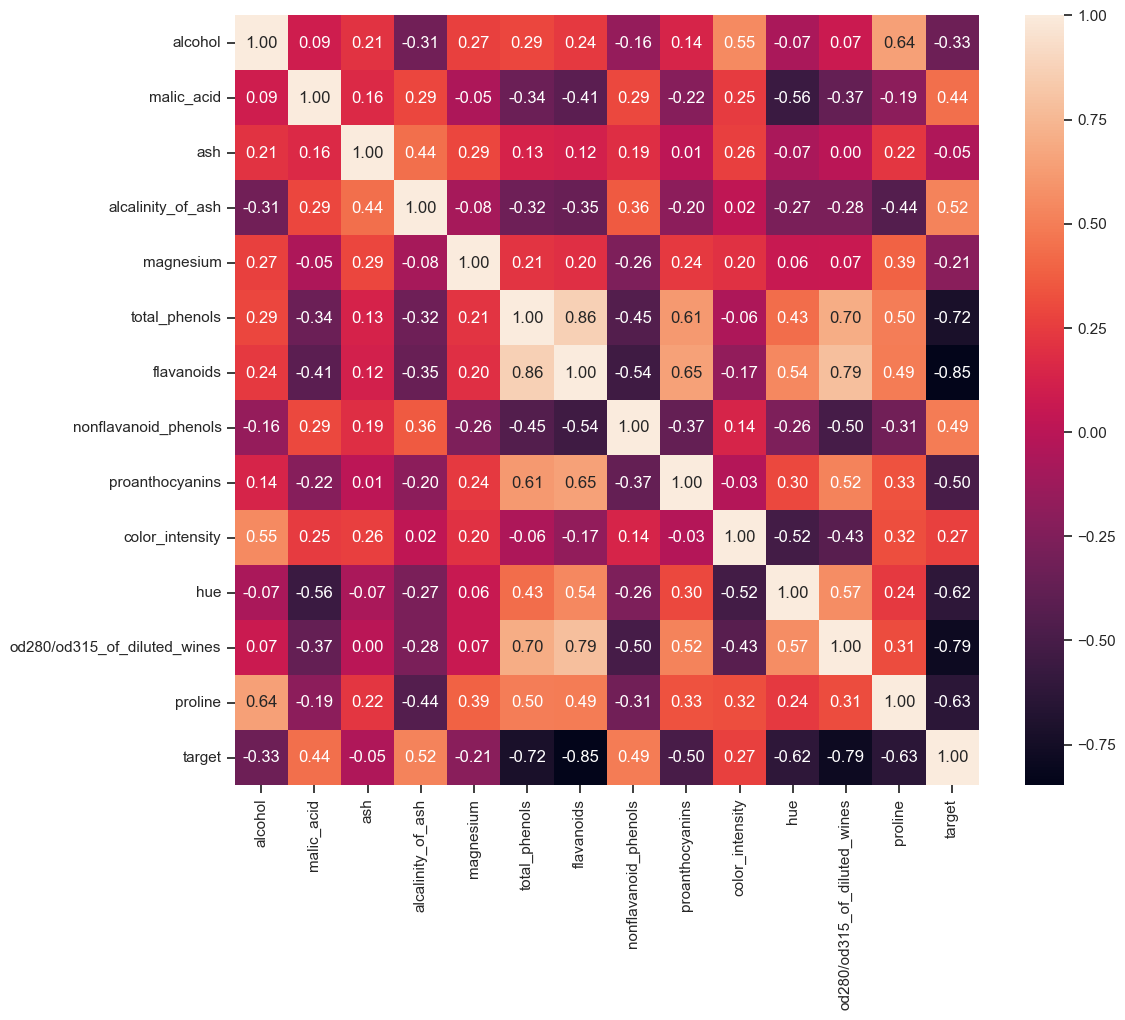

In [6]:

plt.figure(figsize=(12,10))
sns.heatmap(data.corr(), annot=True, fmt='.2f')

<Axes: >

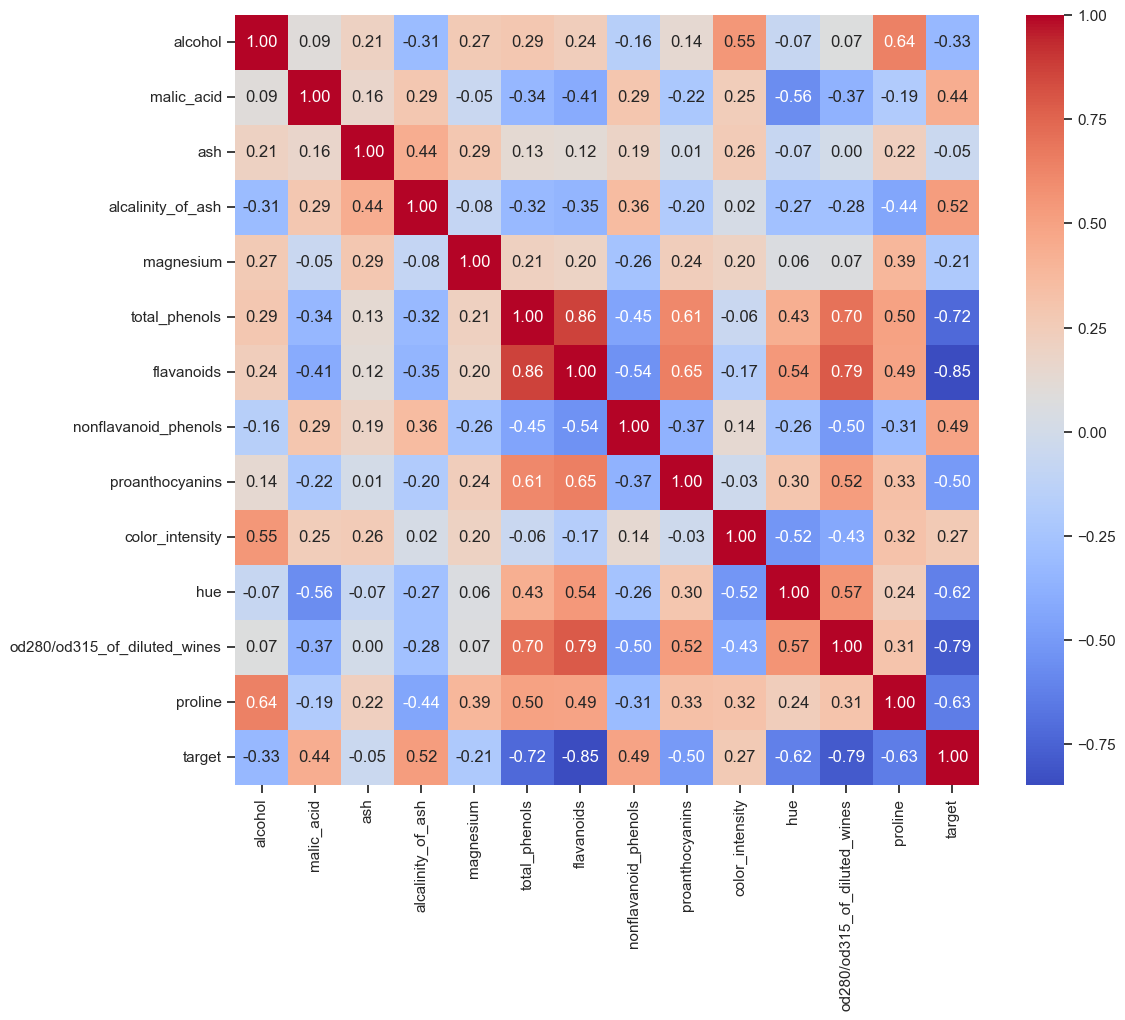

In [42]:
# Изменение цветовой гаммы
plt.figure(figsize=(12,10))
sns.heatmap(data.corr(), cmap='coolwarm', annot=True, fmt='.2f')

<Axes: >

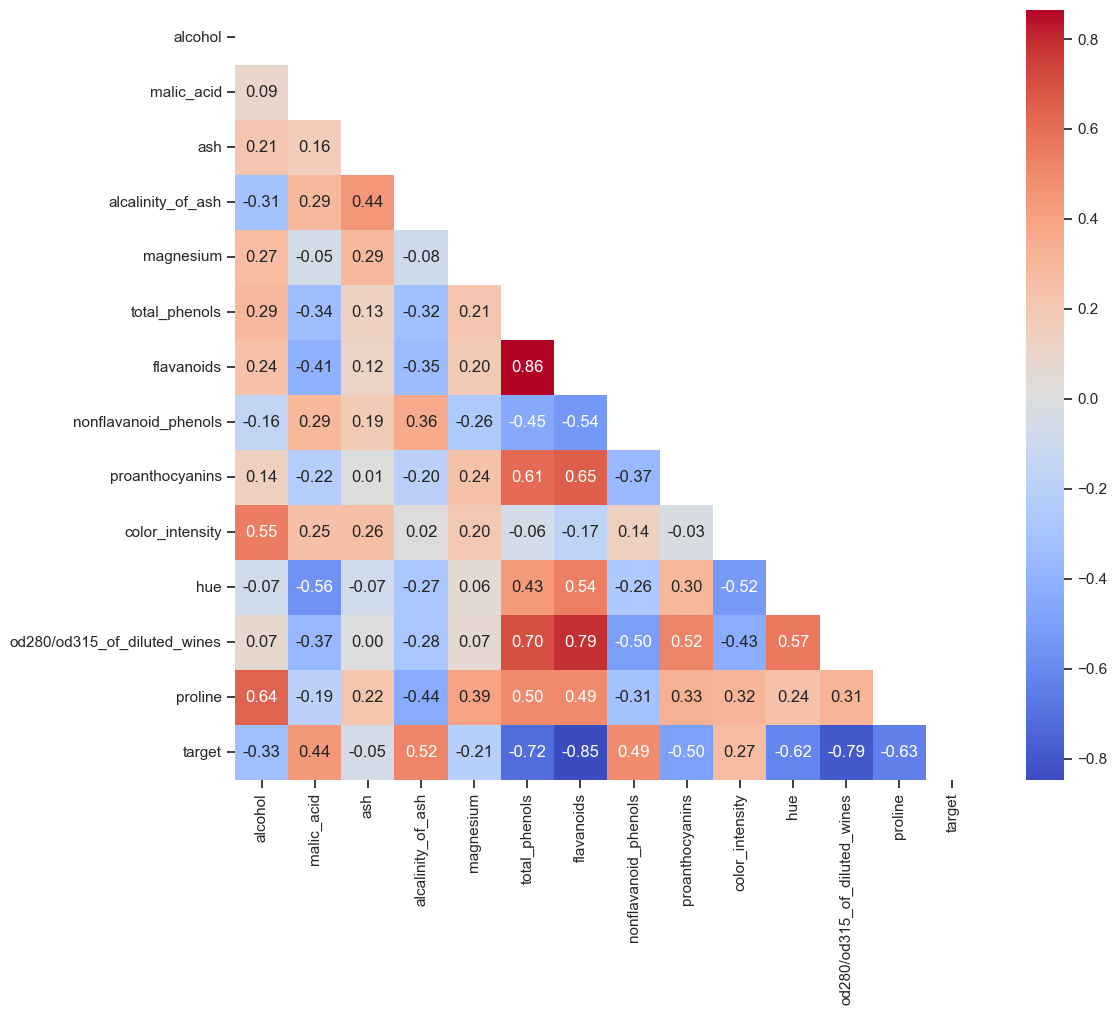

In [43]:
# Треугольный вариант матрицы (верхняя часть)
# Создаем маску для верхней части матрицы
mask = np.triu(np.ones_like(data.corr(), dtype=bool))
plt.figure(figsize=(12,10))
sns.heatmap(data.corr(), mask=mask, annot=True, fmt='.2f', cmap='coolwarm')

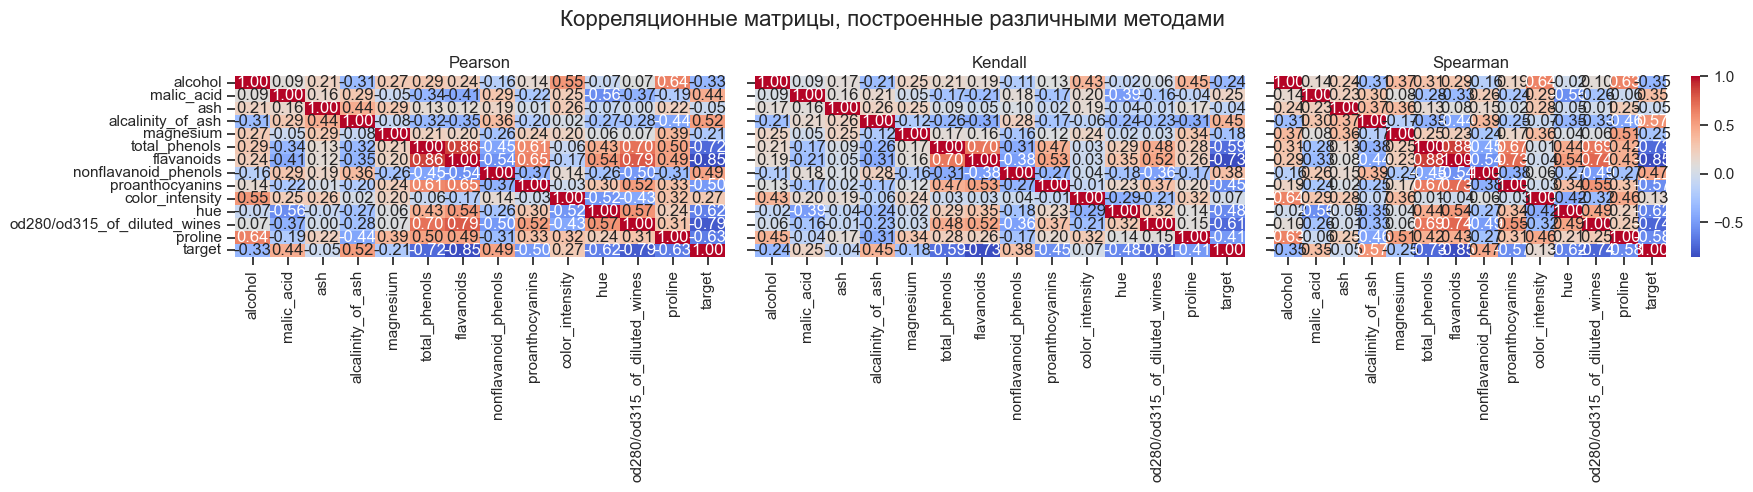

In [44]:
# Сравнение корреляционных матриц, построенных разными методами
fig, ax = plt.subplots(1, 3, sharex='col', sharey='row', figsize=(18,5))

sns.heatmap(data.corr(method='pearson'), ax=ax[0], annot=True, fmt='.2f', cmap='coolwarm', cbar=False)
sns.heatmap(data.corr(method='kendall'), ax=ax[1], annot=True, fmt='.2f', cmap='coolwarm', cbar=False)
sns.heatmap(data.corr(method='spearman'), ax=ax[2], annot=True, fmt='.2f', cmap='coolwarm')

fig.suptitle('Корреляционные матрицы, построенные различными методами', fontsize=16)
ax[0].title.set_text('Pearson')
ax[1].title.set_text('Kendall')
ax[2].title.set_text('Spearman')
plt.tight_layout()

### Тепловая карта с указанием размера

*   Функция `plt.subplots` создает область окна нужного размера, в которую может выводиться график.
*   Параметр `figsize=(размер по горизонтали, размер по вертикали)`.
*   По умолчанию размер задается в дюймах.
*   Функция `sns.heatmap` содержит параметр `ax=ax`, который ссылается на область, созданную `plt.subplots`, поэтому график выводится в данной области.

<Axes: >

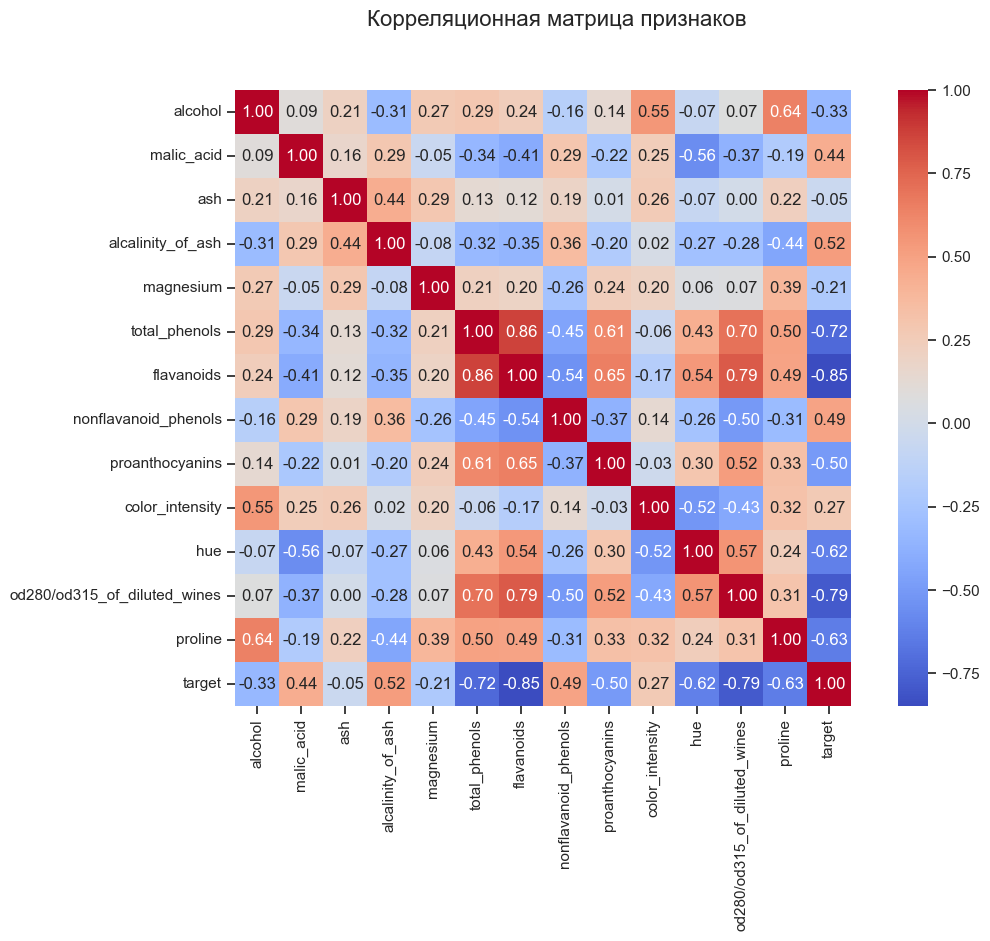

In [45]:
fig, ax = plt.subplots(1, 1, sharex='col', sharey='row', figsize=(12,8))
fig.suptitle('Корреляционная матрица признаков', fontsize=16)
sns.heatmap(data.corr(), ax=ax, annot=True, fmt='.2f', cmap='coolwarm', square=True)

**Выводы по корреляционному анализу:**

Тепловая карта наглядно демонстрирует структуру корреляций в данных. Мы видим несколько групп сильно коррелирующих признаков (красные и синие квадраты):

1.  **Группа фенольных соединений:** `flavanoids`, `total_phenols`, `od280/od315_of_diluted_wines` имеют высокую положительную корреляцию друг с другом. Это говорит о том, что они отражают схожие химические свойства вин.
2.  **Признак `color_intensity`** имеет заметную отрицательную корреляцию с признаками из группы фенолов. Это означает, что вина с более интенсивным цветом содержат меньше фенолов.
3.  Целевой признак (`target`) сильнее всего (отрицательно) коррелирует с группой фенолов, что подтверждает их важность для разделения сортов вин.

Для построения модели машинного обучения можно рассмотреть возможность исключения сильно коррелирующих признаков (например, оставить только `flavanoids` из группы фенолов), чтобы избежать мультиколлинеарности.